In [81]:
import pandas as pd 
import numpy as np
import re
from pathlib import Path

import ipywidgets as widgets
import plotly.graph_objects as go
from IPython.display import display

import utils

In [82]:
sample_catalog_df = pd.read_csv('sample_sweetcat.csv')
corrected_path = Path('observations/Best_RM/linear_corrected')

include_observations = None
exclude_observations = []

normalization_specs = [
    {'columns': utils.LINE_INDICATORS, 'method': 'fractional_mean'},
    {'columns': utils.LINE_INDICATORS, 'method': 'subtract_mean'},
    {'columns': utils.ACTIVITY_INDICATORS, 'method': 'fractional_mean'},
]

rm_df, observation_sample_df = utils.create_rm_analysis_df(
    corrected_path=corrected_path,
    sample_catalog_df=sample_catalog_df,
    include_observations=include_observations,
    exclude_observations=exclude_observations,
    normalization_specs=normalization_specs,
)

all_corrected_files = list(corrected_path.glob('*_linear_corrected.csv'))
selected_files = utils.select_corrected_files(all_corrected_files, include_observations, exclude_observations)

print(f'Loaded {len(selected_files)} corrected observations out of {len(all_corrected_files)} available')
print(f'Total spectra/rows: {len(rm_df)}')
observation_sample_df.head(2)

Loaded 21 corrected observations out of 21 available
Total spectra/rows: 1378


,corrected_file,observation_file,star,Name,gaia_dr3,Teff,eTeff,Logg,eLogg,[Fe/H],...,Gmag,Plx,Distance,Mass_t,Radius_t,SWFlag,Reference,Link,Update,Database
0,HD189733_esp19_3_linear_corrected.csv,HD189733_esp19_3.rdb,HD189733,HD 189733,1827242816201846144,4969.0,48.0,4.3,0.12,-0.08,...,7.4284,50.5668,19.775821,0.751097,0.786858,1,Sousa et al. 2021,https://ui.adsabs.harvard.edu/abs/2021arXiv210...,2021-01-01,EU;NASA
1,HD189733_esp19_4_linear_corrected.csv,HD189733_esp19_4.rdb,HD189733,HD 189733,1827242816201846144,4969.0,48.0,4.3,0.12,-0.08,...,7.4284,50.5668,19.775821,0.751097,0.786858,1,Sousa et al. 2021,https://ui.adsabs.harvard.edu/abs/2021arXiv210...,2021-01-01,EU;NASA


In [83]:
rm_df.columns

Index(['rjd', 'vrad', 'true_vrad', 'fwhm', 'bis_span', 'contrast', 's_mw',
       'ha', 'na', 'ca', 'rhk', 'corrected_file', 'observation_file', 'star',
       'Name', 'gaia_dr3', 'Teff', 'eTeff', 'Logg', 'eLogg', '[Fe/H]',
       'e[Fe/H]', 'Vt', 'eVt', 'Gmag', 'Plx', 'Distance', 'Mass_t', 'Radius_t',
       'SWFlag', 'Reference', 'Link', 'Update', 'Database',
       'vrad_fractional_mean', 'true_vrad_fractional_mean',
       'fwhm_fractional_mean', 'bis_span_fractional_mean',
       'contrast_fractional_mean', 'vrad_subtract_mean',
       'true_vrad_subtract_mean', 'fwhm_subtract_mean',
       'bis_span_subtract_mean', 'contrast_subtract_mean', 's_mw_mean',
       's_mw_std', 'ha_mean', 'ha_std', 'na_mean', 'na_std', 'ca_mean',
       'ca_std', 'rhk_mean', 'rhk_std', 's_mw_fractional_mean',
       'ha_fractional_mean', 'na_fractional_mean', 'ca_fractional_mean',
       'rhk_fractional_mean'],
      dtype='object')

In [84]:
#rm_df[rm_df['star'] == 'WASP-121']

In [85]:
def plot_corrected_observation(obs_name):
    obs_df = rm_df.loc[rm_df['observation_file'] == obs_name].sort_values('rjd')

    fig = go.Figure()
    fig.add_trace(
        go.Scatter(
            x=obs_df['rjd'],
            y=obs_df['true_vrad'],
            mode='markers+lines',
            marker=dict(size=7),
            name='true_vrad',
            hovertemplate='rjd=%{x}<br>true_vrad=%{y}<extra></extra>',
        )
    )
    fig.update_layout(
        title=f'Linear-trend corrected RV: {obs_name}',
        xaxis_title='rjd',
        yaxis_title='true_vrad',
        template='plotly_white',
        hovermode='closest',
    )

    fig.show()


obs_selector = widgets.Dropdown(
    options=sorted(rm_df['observation_file'].unique()),
    description='obs_name:',
)
interactive_plot = widgets.interactive_output(plot_corrected_observation, {'obs_name': obs_selector})
#display(obs_selector, interactive_plot)

WASP 74 ?

WASP122_esp19_1 - ?

WASP131_esp19_1 - ?

In [86]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

holdout_observation = 'HD189733_esp19_3.rdb'

#activity_feature_columns = ['vrad', 'fwhm', 'bis_span', 'contrast', 's_mw', 'ha', 'na', 'ca']
activity_feature_columns = ['vrad_subtract_mean',  'fwhm_fractional_mean', 'bis_span_fractional_mean', 'contrast_fractional_mean',]

optional_feature_columns = ['Teff', 'rhk_mean',]
target_column = 'true_vrad'
candidate_feature_columns = activity_feature_columns + optional_feature_columns
available_feature_columns = [column for column in candidate_feature_columns if column in rm_df.columns]

model_df = rm_df.copy()
for column in available_feature_columns + [target_column]:
    model_df[column] = pd.to_numeric(model_df[column], errors='coerce')

train_df = model_df.loc[model_df['observation_file'] != holdout_observation].dropna(subset=[target_column]).copy()
holdout_df = model_df.loc[model_df['observation_file'] == holdout_observation].dropna(subset=[target_column]).copy()

X_train = train_df[available_feature_columns]
y_train = train_df[target_column]
X_holdout = holdout_df[available_feature_columns]
y_holdout = holdout_df[target_column]

missing_summary = model_df[available_feature_columns + [target_column]].isna().sum().rename('n_missing').to_frame()

print(f'Holdout observation: {holdout_observation}')
print(f'Train rows: {len(train_df)}; holdout rows: {len(holdout_df)}')
print(f'Train observations: {train_df["observation_file"].nunique()}')
#display(missing_summary)


Holdout observation: HD189733_esp19_3.rdb
Train rows: 1337; holdout rows: 41
Train observations: 20


In [87]:
from xgboost import XGBRegressor


def make_xgb_model(random_state=42):
    return XGBRegressor(
        n_estimators=500,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        objective='reg:squarederror',
        random_state=random_state,
    )


def evaluate_holdout_model(model_name, feature_columns):
    feature_columns = [column for column in feature_columns if column in rm_df.columns]
    model = make_xgb_model()
    model.fit(train_df[feature_columns], y_train)

    holdout_sorted_df = holdout_df.sort_values('rjd')
    prediction_df = holdout_sorted_df[['observation_file', 'rjd', 'vrad_subtract_mean', 'true_vrad']].copy()
    prediction_df['predicted_true_vrad'] = model.predict(holdout_sorted_df[feature_columns])

    metrics = {
        'model_name': model_name,
        'n_features': len(feature_columns),
        'features': feature_columns,
        'mae': mean_absolute_error(prediction_df['true_vrad'], prediction_df['predicted_true_vrad']),
        'rmse': mean_squared_error(prediction_df['true_vrad'], prediction_df['predicted_true_vrad']) ** 0.5,
        'r2': r2_score(prediction_df['true_vrad'], prediction_df['predicted_true_vrad']),
    }

    return model, prediction_df, metrics


feature_sets = {'activity_only': activity_feature_columns}
for optional_column in optional_feature_columns:
    feature_sets[f'activity_plus_{optional_column}'] = activity_feature_columns + [optional_column]
feature_sets['activity_plus_all_optional'] = activity_feature_columns + optional_feature_columns

xgb_models = {}
prediction_tables = {}
metric_rows = []

for model_name, feature_columns in feature_sets.items():
    model, prediction_df, metrics = evaluate_holdout_model(model_name, feature_columns)
    xgb_models[model_name] = model
    prediction_tables[model_name] = prediction_df
    metric_rows.append(metrics)

xgb_results_df = pd.DataFrame(metric_rows).sort_values('rmse').reset_index(drop=True)
best_model_name = xgb_results_df.loc[0, 'model_name']
prediction_df = prediction_tables[best_model_name]

display(xgb_results_df[['model_name', 'n_features', 'mae', 'rmse', 'r2', 'features']])
print(f'Best model by RMSE: {best_model_name}')


,model_name,n_features,mae,rmse,r2,features
0,activity_plus_rhk_mean,5,5.830593,7.209465,0.936058,"[vrad_subtract_mean, fwhm_fractional_mean, bis..."
1,activity_only,4,6.039709,7.547186,0.929928,"[vrad_subtract_mean, fwhm_fractional_mean, bis..."
2,activity_plus_all_optional,6,7.536395,9.100375,0.898118,"[vrad_subtract_mean, fwhm_fractional_mean, bis..."
3,activity_plus_Teff,5,7.913256,9.245892,0.894834,"[vrad_subtract_mean, fwhm_fractional_mean, bis..."


Best model by RMSE: activity_plus_rhk_mean


In [88]:
model_to_plot = best_model_name
prediction_df = prediction_tables[model_to_plot]
plot_metrics = xgb_results_df.set_index('model_name').loc[model_to_plot]

display(
    pd.Series(
    {
        'model_name': model_to_plot,
        'mae': plot_metrics['mae'],
        'rmse': plot_metrics['rmse'],
        'r2': plot_metrics['r2'],
        'n_holdout_rows': len(prediction_df),
        'n_train_rows': len(train_df),
    }
    ).to_frame('value')
)

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=prediction_df['rjd'],
        y=prediction_df['vrad_subtract_mean'],
        mode='markers+lines',
        marker=dict(size=7),
        name='vrad',
        hovertemplate='rjd=%{x}<br>vrad=%{y}<extra></extra>',
    )
)
fig.add_trace(
    go.Scatter(
        x=prediction_df['rjd'],
        y=prediction_df['predicted_true_vrad'],
        mode='markers+lines',
        marker=dict(size=7),
        name='predicted true_vrad',
        hovertemplate='rjd=%{x}<br>predicted true_vrad=%{y}<extra></extra>',
    )
)
fig.add_trace(
    go.Scatter(
        x=prediction_df['rjd'],
        y=prediction_df['true_vrad'],
        mode='lines',
        line=dict(width=2, dash='dash'),
        name='actual true_vrad',
        hovertemplate='rjd=%{x}<br>actual true_vrad=%{y}<extra></extra>',
    )
)
fig.update_layout(
    title=f'XGBoost holdout prediction: {holdout_observation} ({model_to_plot})',
    xaxis_title='rjd',
    yaxis_title='RV',
    template='plotly_white',
    hovermode='closest',
)
fig.show()

prediction_df.head()

,value
model_name,activity_plus_rhk_mean
mae,5.830593
rmse,7.209465
r2,0.936058
n_holdout_rows,41
n_train_rows,1337


,observation_file,rjd,vrad_subtract_mean,true_vrad,predicted_true_vrad
0,HD189733_esp19_3.rdb,59437.538315,47.691250,48.11,37.106518
1,HD189733_esp19_3.rdb,59437.542268,45.416104,45.83,38.981045
2,HD189733_esp19_3.rdb,59437.546398,43.248883,43.45,33.377140
3,HD189733_esp19_3.rdb,59437.550744,40.556460,40.94,34.603893
4,HD189733_esp19_3.rdb,59437.554865,38.659248,38.56,29.688560


In [89]:
raw_observation_columns = ['rjd', 'vrad', 'fwhm', 'bis_span', 'contrast', 's_mw', 'ha', 'na', 'ca', 'rhk']
sweetcat_columns = [
    'star', 'Name', 'gaia_dr3', 'Teff', 'eTeff', 'Logg', 'eLogg', '[Fe/H]', 'e[Fe/H]',
    'Vt', 'eVt', 'Gmag', 'Plx', 'Distance', 'Mass_t', 'Radius_t', 'SWFlag',
    'Reference', 'Link', 'Update', 'Database'
]


def normalize_star_name(star_name):
    return re.sub(r"[^a-z0-9]", "", str(star_name).lower())

def read_rdb_observation(obs_path):
    obs_df = pd.read_csv(obs_path, sep='\t', skiprows=[1])
    for column in obs_df.columns:
        numeric_column = pd.to_numeric(obs_df[column], errors='coerce')
        if numeric_column.notna().sum() > 0:
            obs_df[column] = numeric_column

    return obs_df


def find_star_rdb_files(star_name, observations_dir='observations/test_observations'):
    observations_dir = Path(observations_dir)
    star_key = normalize_star_name(star_name)
    rdb_files = sorted(
        obs_path for obs_path in observations_dir.glob('*.rdb')
        if normalize_star_name(obs_path.stem).startswith(star_key)
    )

    if not rdb_files:
        raise FileNotFoundError(f'No .rdb files found for {star_name} in {observations_dir}')

    return rdb_files


def extract_observation_columns(obs_df, columns=raw_observation_columns):
    extracted_df = pd.DataFrame(index=obs_df.index)
    for column in columns:
        extracted_df[column] = obs_df[column] if column in obs_df.columns else np.nan

    return extracted_df


def load_sweetcat_catalog(
    sweetcat_url='https://sweetcat.iastro.pt/catalog/SWEETCAT_Dataframe.csv',
):
    sweetcat_df = pd.read_csv(sweetcat_url)
    if 'Unnamed: 0' in sweetcat_df.columns:
        sweetcat_df = sweetcat_df.drop(columns='Unnamed: 0')

    return sweetcat_df


def project_star_name_from_sweetcat(row):
    if 'star' in row and pd.notna(row['star']):
        return row['star']
    if 'hd' in row and pd.notna(row['hd']):
        try:
            return f"HD{int(float(row['hd']))}"
        except (TypeError, ValueError):
            return f"HD{row['hd']}"

    return str(row['Name'])


def standardize_sweetcat_row(row, columns=sweetcat_columns):
    row = row.copy()
    row['star'] = project_star_name_from_sweetcat(row)

    for column in columns:
        if column not in row.index:
            row[column] = np.nan

    return row[columns]


def normalize_hd_catalog_value(value):
    if pd.isna(value):
        return ''
    try:
        return normalize_star_name(f'HD{int(float(value))}')
    except (TypeError, ValueError):
        return normalize_star_name(f'HD{value}')


def find_sweetcat_matches(star_name, sweetcat_df):
    star_key = normalize_star_name(star_name)
    catalog_df = sweetcat_df.copy()

    if 'star' in catalog_df.columns:
        catalog_df['_star_key'] = catalog_df['star'].map(normalize_star_name)
    else:
        catalog_df['_star_key'] = ''

    if 'Name' in catalog_df.columns:
        catalog_df['_name_key'] = catalog_df['Name'].map(normalize_star_name)
    else:
        catalog_df['_name_key'] = ''

    if 'hd' in catalog_df.columns:
        catalog_df['_hd_key'] = catalog_df['hd'].map(normalize_hd_catalog_value)
    else:
        catalog_df['_hd_key'] = ''

    return catalog_df.loc[
        (catalog_df['_star_key'] == star_key)
        | (catalog_df['_name_key'] == star_key)
        | (catalog_df['_hd_key'] == star_key)
    ]


def sweetcat_row_for_star(star_name, sweetcat_df=None):
    if sweetcat_df is None:
        sweetcat_df = load_sweetcat_catalog()

    matches = find_sweetcat_matches(star_name, sweetcat_df)
    if matches.empty:
        raise ValueError(f'{star_name} was not found in SWEET-Cat.')

    return standardize_sweetcat_row(
        matches.drop(columns=['_star_key', '_name_key', '_hd_key']).iloc[0]
    )


def add_stellar_parameters(obs_df, stellar_row):
    enriched_df = obs_df.copy()
    for column, value in stellar_row.items():
        enriched_df[column] = value

    return enriched_df


def build_raw_observation_table(
    star_name,
    observations_dir='observations/test_observations',
    observation_columns=raw_observation_columns,
    sweetcat_df=None,
):
    stellar_row = sweetcat_row_for_star(star_name, sweetcat_df=sweetcat_df)
    tables = []

    for obs_path in find_star_rdb_files(star_name, observations_dir=observations_dir):
        obs_df = read_rdb_observation(obs_path)
        obs_df = extract_observation_columns(obs_df, columns=observation_columns)
        obs_df.insert(0, 'observation_file', obs_path.name)
        obs_df.insert(0, 'star_from_file', star_name)
        obs_df = add_stellar_parameters(obs_df, stellar_row)
        tables.append(obs_df)

    return pd.concat(tables, ignore_index=True)


def save_raw_observation_csv(
    star_name,
    observations_dir='observations/test_observations',
    output_dir='observations/test_observations/raw_csv',
    observation_columns=raw_observation_columns,
    sweetcat_df=None,
):
    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)

    raw_df = build_raw_observation_table(
        star_name,
        observations_dir=observations_dir,
        observation_columns=observation_columns,
        sweetcat_df=sweetcat_df,
    )
    output_path = output_dir / f'{normalize_star_name(star_name)}_raw_sweetcat.csv'
    raw_df.to_csv(output_path, index=False)

    return raw_df, output_path


star_to_prepare = 'HD22496'
star_raw_df, star_raw_csv_path = save_raw_observation_csv(star_to_prepare)

print(f'Saved raw SWEET-Cat-enriched CSV: {star_raw_csv_path}')
print(f'Rows: {len(star_raw_df)}; observations: {star_raw_df["observation_file"].nunique()}')
display(star_raw_df.head())



Saved raw SWEET-Cat-enriched CSV: observations/test_observations/raw_csv/hd22496_raw_sweetcat.csv
Rows: 80; observations: 1


,star_from_file,observation_file,rjd,vrad,fwhm,bis_span,contrast,s_mw,ha,na,...,Gmag,Plx,Distance,Mass_t,Radius_t,SWFlag,Reference,Link,Update,Database
0,HD22496,HD22496_ESPRESSO19_1.rdb,58721.841555,21573.070746,5634.462459,22.715014,56.147090,874.597149,0.352597,0.097709,...,8.020994,73.5199,13.60176,0.6357,0.642317,1,Sousa et al. 2024,https://arxiv.org/abs/2409.11965,2024-09-19,EU;NASA
1,HD22496,HD22496_ESPRESSO19_1.rdb,58725.853501,21571.273807,5646.370345,26.941631,56.045334,925.846417,0.360024,0.099028,...,8.020994,73.5199,13.60176,0.6357,0.642317,1,Sousa et al. 2024,https://arxiv.org/abs/2409.11965,2024-09-19,EU;NASA
2,HD22496,HD22496_ESPRESSO19_1.rdb,58731.841940,21568.357191,5631.082980,25.904744,56.220869,870.504200,0.345778,0.097464,...,8.020994,73.5199,13.60176,0.6357,0.642317,1,Sousa et al. 2024,https://arxiv.org/abs/2409.11965,2024-09-19,EU;NASA
3,HD22496,HD22496_ESPRESSO19_1.rdb,58737.843932,21572.784202,5628.129192,25.327489,56.255636,860.858435,0.345964,0.097340,...,8.020994,73.5199,13.60176,0.6357,0.642317,1,Sousa et al. 2024,https://arxiv.org/abs/2409.11965,2024-09-19,EU;NASA
4,HD22496,HD22496_ESPRESSO19_1.rdb,58741.712135,21569.370671,5629.892175,27.568874,56.256258,856.025108,0.348875,0.097338,...,8.020994,73.5199,13.60176,0.6357,0.642317,1,Sousa et al. 2024,https://arxiv.org/abs/2409.11965,2024-09-19,EU;NASA


In [90]:
model_to_apply = 'activity_plus_Teff'  # best_model_name
model = xgb_models[model_to_apply]
feature_columns = list(xgb_results_df.set_index('model_name').loc[model_to_apply, 'features'])

star_raw_for_model_df = pd.read_csv(star_raw_csv_path)
star_df = utils.apply_normalization_specs(
    star_raw_for_model_df,
    normalization_specs=normalization_specs,
)

missing_feature_columns = [column for column in feature_columns if column not in star_df.columns]
if missing_feature_columns:
    raise KeyError(f'Missing derived feature columns for prediction: {missing_feature_columns}')

star_prediction_df = star_df.copy()
for column in feature_columns:
    star_prediction_df[column] = pd.to_numeric(star_prediction_df[column], errors='coerce')

star_prediction_df = star_prediction_df.dropna(subset=feature_columns).sort_values(
    ['observation_file', 'rjd']
).copy()
star_prediction_df['predicted_true_vrad'] = model.predict(star_prediction_df[feature_columns])

display(
    pd.Series(
    {
        'model_name': model_to_apply,
        'features': feature_columns,
        'n_star_rows': len(star_prediction_df),
        'n_star_observations': star_prediction_df['observation_file'].nunique(),
        'n_train_rows': len(train_df),
    }
    ).to_frame('value')
)

fig = go.Figure()
for obs_name, obs_df in star_prediction_df.groupby('observation_file', sort=True):
    fig.add_trace(
        go.Scatter(
            x=obs_df['rjd'],
            y=obs_df['vrad_subtract_mean'],
            mode='markers+lines',
            marker=dict(size=7),
            name=f'{obs_name} vrad',
            hovertemplate='obs=%{fullData.name}<br>rjd=%{x}<br>vrad=%{y}<extra></extra>',
        )
    )
    fig.add_trace(
        go.Scatter(
            x=obs_df['rjd'],
            y=obs_df['predicted_true_vrad'],
            mode='markers+lines',
            marker=dict(size=7, symbol='diamond'),
            name=f'{obs_name} predicted true_vrad',
            hovertemplate='obs=%{fullData.name}<br>rjd=%{x}<br>predicted true_vrad=%{y}<extra></extra>',
        )
    )
fig.update_layout(
    title=f'XGBoost prediction for star ({model_to_apply})',
    xaxis_title='rjd',
    yaxis_title='RV',
    template='plotly_white',
    hovermode='closest',
)
fig.show()

star_prediction_df[['observation_file', 'rjd', 'vrad', 'predicted_true_vrad', *feature_columns]].head()

,value
model_name,activity_plus_Teff
features,"[vrad_subtract_mean, fwhm_fractional_mean, bis..."
n_star_rows,80
n_star_observations,1
n_train_rows,1337


,observation_file,rjd,vrad,predicted_true_vrad,vrad_subtract_mean,fwhm_fractional_mean,bis_span_fractional_mean,contrast_fractional_mean,Teff
0,HD22496_ESPRESSO19_1.rdb,58721.841555,21573.070746,4.582554,1.535941,0.002469,-0.086074,-0.002809,4460.0
1,HD22496_ESPRESSO19_1.rdb,58725.853501,21571.273807,2.875208,-0.260998,0.004587,0.083981,-0.004617,4460.0
2,HD22496_ESPRESSO19_1.rdb,58731.841940,21568.357191,0.072926,-3.177614,0.001867,0.042263,-0.001499,4460.0
3,HD22496_ESPRESSO19_1.rdb,58737.843932,21572.784202,3.323292,1.249397,0.001342,0.019037,-0.000882,4460.0
4,HD22496_ESPRESSO19_1.rdb,58741.712135,21569.370671,0.285646,-2.164134,0.001656,0.109218,-0.000871,4460.0


In [91]:
rm_df.columns

Index(['rjd', 'vrad', 'true_vrad', 'fwhm', 'bis_span', 'contrast', 's_mw',
       'ha', 'na', 'ca', 'rhk', 'corrected_file', 'observation_file', 'star',
       'Name', 'gaia_dr3', 'Teff', 'eTeff', 'Logg', 'eLogg', '[Fe/H]',
       'e[Fe/H]', 'Vt', 'eVt', 'Gmag', 'Plx', 'Distance', 'Mass_t', 'Radius_t',
       'SWFlag', 'Reference', 'Link', 'Update', 'Database',
       'vrad_fractional_mean', 'true_vrad_fractional_mean',
       'fwhm_fractional_mean', 'bis_span_fractional_mean',
       'contrast_fractional_mean', 'vrad_subtract_mean',
       'true_vrad_subtract_mean', 'fwhm_subtract_mean',
       'bis_span_subtract_mean', 'contrast_subtract_mean', 's_mw_mean',
       's_mw_std', 'ha_mean', 'ha_std', 'na_mean', 'na_std', 'ca_mean',
       'ca_std', 'rhk_mean', 'rhk_std', 's_mw_fractional_mean',
       'ha_fractional_mean', 'na_fractional_mean', 'ca_fractional_mean',
       'rhk_fractional_mean'],
      dtype='object')

In [92]:
star_prediction_df[['vrad_subtract_mean', 'predicted_true_vrad']].describe()

,vrad_subtract_mean,predicted_true_vrad
count,8.000000e+01,80.000000
mean,1.000444e-12,2.385576
std,3.054806e+00,2.843976
min,-6.009221e+00,-2.640576
25%,-2.228719e+00,0.232466
50%,6.933855e-02,2.161897
75%,2.007211e+00,4.437480
max,7.224464e+00,10.562185


# New

HD209458_esp19_2_linear_corrected


In [93]:
from astropy.timeseries import LombScargle

gls_input_df = (
    star_prediction_df[['rjd', 'predicted_true_vrad']]
    .dropna()
    .sort_values('rjd')
    .copy()
)

gls = LombScargle(
    gls_input_df['rjd'].to_numpy(),
    gls_input_df['predicted_true_vrad'].to_numpy(),
    center_data=True,
    fit_mean=True,
)

min_period = 1
max_period = 50

min_frequency = 1 / max_period
max_frequency = 1 / min_period

frequency, power = gls.autopower(
    minimum_frequency=min_frequency,
    maximum_frequency=max_frequency,
)

#frequency, power = gls.autopower()


best_frequency = frequency[np.argmax(power)]
best_period = 1 / best_frequency

gls_periodogram_df = pd.DataFrame(
    {
        'frequency': frequency,
        'period': 1 / frequency,
        'power': power,
    }
).sort_values('period')

fig = go.Figure()
fig.add_trace(
    go.Scatter(
        x=gls_periodogram_df['period'],
        y=gls_periodogram_df['power'],
        mode='lines',
        name='GLS power',
        hovertemplate='period=%{x:.6f} d<br>power=%{y:.6f}<extra></extra>',
    )
)
fig.add_vline(
    x=best_period,
    line_dash='dash',
    line_color='crimson',
    annotation_text=f'best period = {best_period:.6f} d',
    annotation_position='top right',
)
fig.update_layout(
    title='GLS periodogram of predicted RV',
    xaxis_title='Period [days]',
    yaxis_title='Power',
)
fig.update_xaxes(type='log', range=[np.log10(1), np.log10(50)])
fig.show()

pd.Series(
    {
        'best_frequency': best_frequency,
        'best_period_days': best_period,
        'max_power': power.max(),
    }
)


best_frequency       0.027287
best_period_days    36.647376
max_power            0.264312
dtype: float64

In [94]:
target_window_min = 5.05
target_window_max = 5.15
background_window_min = 6.0
background_window_max = 8.0
eps = 1e-12

target_mask = (
    (gls_periodogram_df['period'] >= target_window_min)
    & (gls_periodogram_df['period'] <= target_window_max)
)

background_mask = (
    (gls_periodogram_df['period'] >= background_window_min)
    & (gls_periodogram_df['period'] <= background_window_max)
)

target_window_df = gls_periodogram_df.loc[target_mask].copy()
background_window_df = gls_periodogram_df.loc[background_mask].copy()

if target_window_df.empty:
    raise ValueError('No GLS samples found in target window.')
if background_window_df.empty:
    raise ValueError('No GLS samples found in background window.')

peak_idx = target_window_df['power'].idxmax()
peak_period = gls_periodogram_df.loc[peak_idx, 'period']
peak_power = gls_periodogram_df.loc[peak_idx, 'power']
background_median_power = background_window_df['power'].median()

gls_ratio = peak_power / max(background_median_power, eps)

pd.Series(
    {
        'target_window_min': target_window_min,
        'target_window_max': target_window_max,
        'background_window_min': background_window_min,
        'background_window_max': background_window_max,
        'peak_period_in_target_window': peak_period,
        'peak_power_in_target_window': peak_power,
        'median_power_in_background_window': background_median_power,
        'gls_ratio': gls_ratio,
    }
).to_frame('value')


,value
target_window_min,5.050000
target_window_max,5.150000
background_window_min,6.000000
background_window_max,8.000000
peak_period_in_target_window,5.091321
peak_power_in_target_window,0.109989
median_power_in_background_window,0.012664
gls_ratio,8.685348


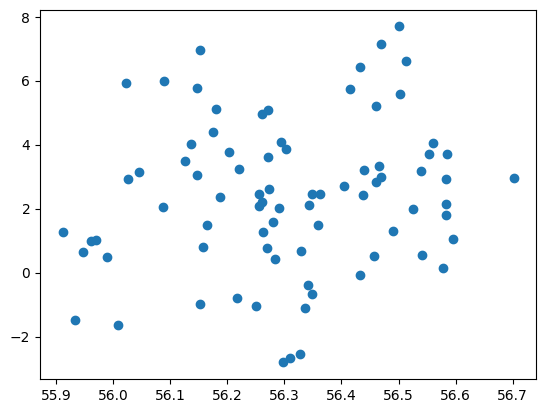

In [95]:
import matplotlib.pyplot as plt     
plt.scatter(star_prediction_df['contrast'], star_prediction_df['predicted_true_vrad'] - star_prediction_df['vrad_subtract_mean'])

In [96]:
rm_df.columns

Index(['rjd', 'vrad', 'true_vrad', 'fwhm', 'bis_span', 'contrast', 's_mw',
       'ha', 'na', 'ca', 'rhk', 'corrected_file', 'observation_file', 'star',
       'Name', 'gaia_dr3', 'Teff', 'eTeff', 'Logg', 'eLogg', '[Fe/H]',
       'e[Fe/H]', 'Vt', 'eVt', 'Gmag', 'Plx', 'Distance', 'Mass_t', 'Radius_t',
       'SWFlag', 'Reference', 'Link', 'Update', 'Database',
       'vrad_fractional_mean', 'true_vrad_fractional_mean',
       'fwhm_fractional_mean', 'bis_span_fractional_mean',
       'contrast_fractional_mean', 'vrad_subtract_mean',
       'true_vrad_subtract_mean', 'fwhm_subtract_mean',
       'bis_span_subtract_mean', 'contrast_subtract_mean', 's_mw_mean',
       's_mw_std', 'ha_mean', 'ha_std', 'na_mean', 'na_std', 'ca_mean',
       'ca_std', 'rhk_mean', 'rhk_std', 's_mw_fractional_mean',
       'ha_fractional_mean', 'na_fractional_mean', 'ca_fractional_mean',
       'rhk_fractional_mean'],
      dtype='object')

In [97]:
export_dir = Path('model_tables')
export_dir.mkdir(exist_ok=True)

rm_export_path = export_dir / 'rm_df_full.csv'
rm_df.to_csv(rm_export_path, index=False)

star_export_df = star_df.reindex(columns=rm_df.columns)
star_export_path = export_dir / 'hd22496_full.csv'
star_export_df.to_csv(star_export_path, index=False)

pd.Series(
    {
        'rm_export_path': str(rm_export_path),
        'rm_n_rows': len(rm_df),
        'rm_n_columns': len(rm_df.columns),
        'star_export_path': str(star_export_path),
        'star_n_rows': len(star_export_df),
        'star_n_columns': len(star_export_df.columns),
    }
).to_frame('value')


,value
rm_export_path,model_tables/rm_df_full.csv
rm_n_rows,1378
rm_n_columns,59
star_export_path,model_tables/hd22496_full.csv
star_n_rows,80
star_n_columns,59


In [98]:
to_save = star_prediction_df[['rjd', 'predicted_true_vrad']].copy()
to_save = to_save.rename(columns={'predicted_true_vrad': 'vrad'})
to_save['svrad'] = 0.2

output_path = Path('hd22496_prediction.rdb')
with output_path.open('w', encoding='utf-8') as f:
    f.write('rjd\tvrad\tsvrad\n')
    f.write('---\t---\t---\n')
    to_save.to_csv(f, index=False, sep='\t', header=False)

output_path

PosixPath('hd22496_prediction.rdb')